In [1]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import matplotlib.patches as mpatches
from utils import *
import matplotlib.colors as mcolors



In [14]:
def visualize(dimensions, problems, algorithms, runs,
              line_plot_y=False, plot_y=False, data_dir=None, save=False,
              popsize=50, fig_dir='figures_clustering_new_kmeans'):
    """
    For each (dimension, problem, algorithm, run): plot the cluster-occupancy
    heatmap (agents per cluster per iteration), optionally alongside the
    per-cluster best scaled fitness (as a line plot or heatmap).
    """
    if data_dir is None:
        data_dir = 'data/clustering_latest'

    for dimension in dimensions:
        directory = f'{data_dir}/cluster_distributions/dim_{dimension}'

        for problem in problems:
            # ---- cluster centers (used to label cluster columns) ----
            centers_path = f'{data_dir}/cluster_centers/dim_{dimension}/{problem}.csv'
            if not os.path.isfile(centers_path):
                print(f"  missing cluster centers: {centers_path}")
                continue
            cluster_centers = pd.read_csv(centers_path, index_col=0)
            cluster_centers = {
                index: ', '.join(str(round(row[c], 2)) for c in row.keys())
                for index, row in cluster_centers.iterrows()
            }

            solutions = pd.read_parquet(
                f'{data_dir}/clustering_results/dim_{dimension}/{problem}.parquet')

            file_loc = f'{directory}/{problem}.csv'
            if not os.path.isfile(file_loc):
                print(f"  missing cluster distributions: {file_loc}")
                continue

            df = pd.read_csv(file_loc, index_col=[0, 1, 2])
            df.columns = [f'{int(c)} (Center: {cluster_centers[int(c)]})' for c in df.columns]

            for a in algorithms:
                for run in runs:
                    # ---- guard: this (algorithm, run) may not exist ----
                    try:
                        occupancy = df.loc[a, run]
                    except KeyError:
                        print(f"  no data for {problem} / {a} / run {run}, skipping")
                        continue

                    s = (solutions.query('algorithm==@a and run==@run')
                         .groupby(['iteration', 'cluster'])['scaled_raw_y'])
                    s_min = s.min().cummin().to_frame().reset_index()
                    if s_min.empty:
                        print(f"  no solutions for {problem} / {a} / run {run}, skipping")
                        continue

                    # ---- figure size: scale height with the number of ITERATIONS
                    # (rows of the heatmap), not an arbitrary divisor. Guarded so
                    # an empty/NaN max can't blow up int().
                    n_iters = int(occupancy.shape[0])
                    fig_h = max(6, n_iters * 0.35)
                    fig_w = 16 if plot_y else 9

                    fig, axes = plt.subplots(1, 2 if plot_y else 1,
                                             figsize=(fig_w, fig_h), squeeze=False)
                    axes = axes[0]

                    # ---- left: cluster occupancy heatmap ----
                    sns.heatmap(occupancy.replace(0, np.nan), annot=True, fmt='.0f',
                                ax=axes[0], cmap='YlGnBu', vmin=0, vmax=popsize,
                                cbar_kws={'label': 'agents in cluster'})
                    axes[0].set_title(f'{a} — run {run} — {problem} (dim {dimension})\n'
                                      f'cluster occupancy',
                                      fontsize=11, fontweight='bold')
                    axes[0].set_xlabel('Cluster')
                    axes[0].set_ylabel('Iteration')

                    # ---- right (optional): best scaled fitness per cluster ----
                    if plot_y:
                        if line_plot_y:
                            sns.lineplot(data=s_min, x='iteration', y='scaled_raw_y',
                                         hue='cluster', style='cluster', palette='tab10',
                                         markers=True, dashes=False, ax=axes[1])
                            axes[1].set_xlabel('Iteration')
                            axes[1].set_ylabel('Scaled Raw Y (running min)')
                        else:
                            s_min_pivoted = s_min.pivot(index='iteration', columns='cluster',
                                                        values='scaled_raw_y')
                            s_min_pivoted.columns = [
                                f'{int(c)} (Center: {cluster_centers[int(c)]})'
                                for c in s_min_pivoted.columns
                            ]
                            # LogNorm can't handle <=0; clip to a small positive floor
                            plot_vals = s_min_pivoted.clip(lower=1e-8)
                            sns.heatmap(plot_vals, annot=True, ax=axes[1], cmap='YlGnBu',
                                        fmt='.3f', norm=mcolors.LogNorm(),
                                        cbar_kws={'label': 'scaled raw y (log)'})
                            axes[1].set_xlabel('Cluster')
                            axes[1].set_ylabel('Iteration')

                        axes[1].set_title(f'{a} — run {run} — {problem} (dim {dimension})\n'
                                          f'best scaled fitness per cluster',
                                          fontsize=11, fontweight='bold')

                    plt.tight_layout()

                    if save:
                        os.makedirs(fig_dir, exist_ok=True)
                        file_name = f'{problem}_{a}_run_{run}_dim_{dimension}.pdf'
                        plt.savefig(f'{fig_dir}/{file_name}', bbox_inches='tight')

                    plt.show()
                    plt.close(fig)

In [17]:
def visualize_multi(dimensions, problems, algorithms, runs,
                    line_plot_y=False, plot_y=False, data_dir=None, save=False,
                    popsize=50, fig_dir='figures_clustering_new_kmeans'):
    """
    Same as visualize(), but stacks all algorithms into ONE figure (one row per
    algorithm) so they can be compared side by side on the same problem/run.
    """
    if data_dir is None:
        data_dir = 'data/clustering_latest'
 
    for dimension in dimensions:
        directory = f'{data_dir}/cluster_distributions/dim_{dimension}'
 
        for problem in problems:
            centers_path = f'{data_dir}/cluster_centers/dim_{dimension}/{problem}.csv'
            if not os.path.isfile(centers_path):
                print(f"  missing cluster centers: {centers_path}")
                continue
            cluster_centers = pd.read_csv(centers_path, index_col=0)
            cluster_count = cluster_centers.shape[0]
            cluster_centers = {
                index: ', '.join(str(round(row[c], 2)) for c in row.keys())
                for index, row in cluster_centers.iterrows()
            }
 
            solutions = pd.read_parquet(
                f'{data_dir}/clustering_results/dim_{dimension}/{problem}.parquet')
 
            file_loc = f'{directory}/{problem}.csv'
            if not os.path.isfile(file_loc):
                print(f"  missing cluster distributions: {file_loc}")
                continue
 
            df = pd.read_csv(file_loc, index_col=[0, 1, 2])
            df.columns = [f'{int(c)} (Center: {cluster_centers[int(c)]})' for c in df.columns]
 
            for run in runs:
                # ---- figure size: height scales with the NUMBER OF ALGORITHMS
                # (one row each), not the dimension. The original used
                # 3*dimension*len(algorithms), which at dim 10 with 8 algorithms
                # is a 240-inch-tall figure.
                n_rows = len(algorithms)
                fig_w = max(14, cluster_count * 1.2) if plot_y else 10
                fig_h = 4.5 * n_rows
 
                fig, all_axes = plt.subplots(n_rows, 2 if plot_y else 1,
                                             figsize=(fig_w, fig_h),
                                             squeeze=False, sharex=False)
 
                for a_index, a in enumerate(algorithms):
                    axes = all_axes[a_index]
 
                    try:
                        occupancy = df.loc[a, run]
                    except KeyError:
                        print(f"  no data for {problem} / {a} / run {run}, skipping row")
                        axes[0].set_visible(False)
                        if plot_y:
                            axes[1].set_visible(False)
                        continue
 
                    s = (solutions.query('algorithm==@a and run==@run')
                         .groupby(['iteration', 'cluster'])['scaled_raw_y'])
                    s_min = s.min().to_frame().reset_index()
 
                    # ---- left: cluster occupancy ----
                    sns.heatmap(occupancy.replace(0, np.nan), annot=True, fmt='.0f',
                                ax=axes[0], vmin=0, vmax=popsize, cmap='YlGnBu',
                                cbar_kws={'label': 'agents in cluster'})
                    axes[0].set_title(f'{a} — run {run} — {problem} (dim {dimension}): '
                                      f'cluster occupancy',
                                      fontsize=11, fontweight='bold')
                    axes[0].set_xlabel('Cluster')
                    axes[0].set_ylabel('Iteration')
 
                    # ---- right (optional): best scaled fitness per cluster ----
                    if plot_y:
                        if s_min.empty:
                            axes[1].set_visible(False)
                            continue
                        if line_plot_y:
                            sns.lineplot(data=s_min, x='iteration', y='scaled_raw_y',
                                         hue='cluster', style='cluster', palette='tab10',
                                         markers=True, dashes=False, ax=axes[1])
                            axes[1].set_xlabel('Iteration')
                            axes[1].set_ylabel('Scaled Raw Y')
                        else:
                            s_min_pivoted = s_min.pivot(index='iteration', columns='cluster',
                                                        values='scaled_raw_y')
                            s_min_pivoted.columns = [
                                f'{int(c)} (Center: {cluster_centers[int(c)]})'
                                for c in s_min_pivoted.columns
                            ]
                            sns.heatmap(s_min_pivoted, annot=True, fmt='.2f', ax=axes[1],
                                        vmin=0, vmax=1, cmap='YlGnBu',
                                        cbar_kws={'label': 'scaled raw y'})
                            axes[1].set_xlabel('Cluster')
                            axes[1].set_ylabel('Iteration')
 
                        axes[1].set_title(f'{a} — run {run}: min scaled y per cluster',
                                          fontsize=11, fontweight='bold')
 
                # NOTE: plt.margins(0, tight=True) removed - it fights with
                # tight_layout() and can crop the subplot titles.
                plt.tight_layout()
 
                if save:
                    os.makedirs(fig_dir, exist_ok=True)
                    algo_str = '+'.join(algorithms)
                    file_name = (f"{data_dir.split('/')[-1]}_{problem}_{algo_str}"
                                 f"_run_{run}_dim_{dimension}.pdf")
                    plt.savefig(f'{fig_dir}/{file_name}', bbox_inches='tight')
 
                plt.show()
                plt.close(fig)


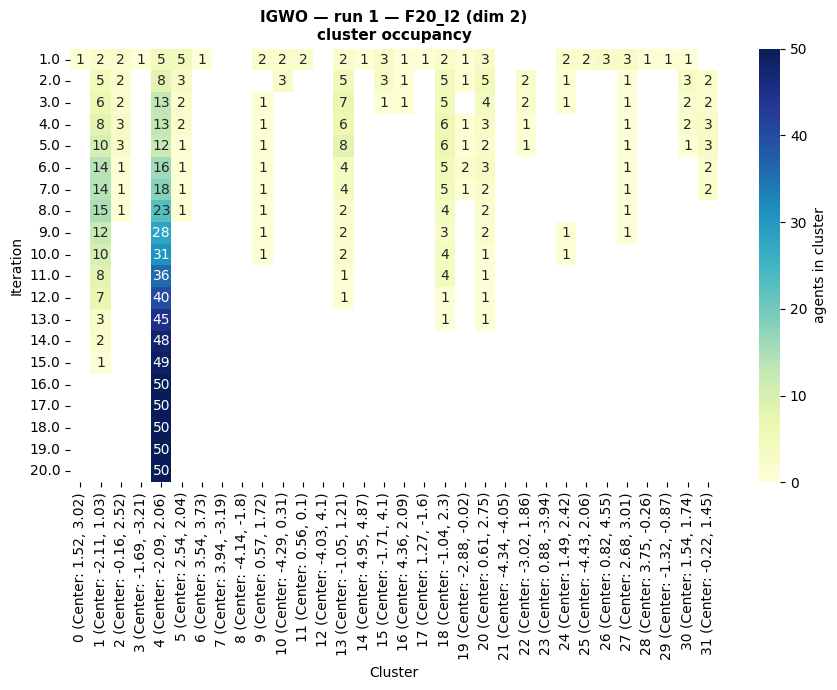

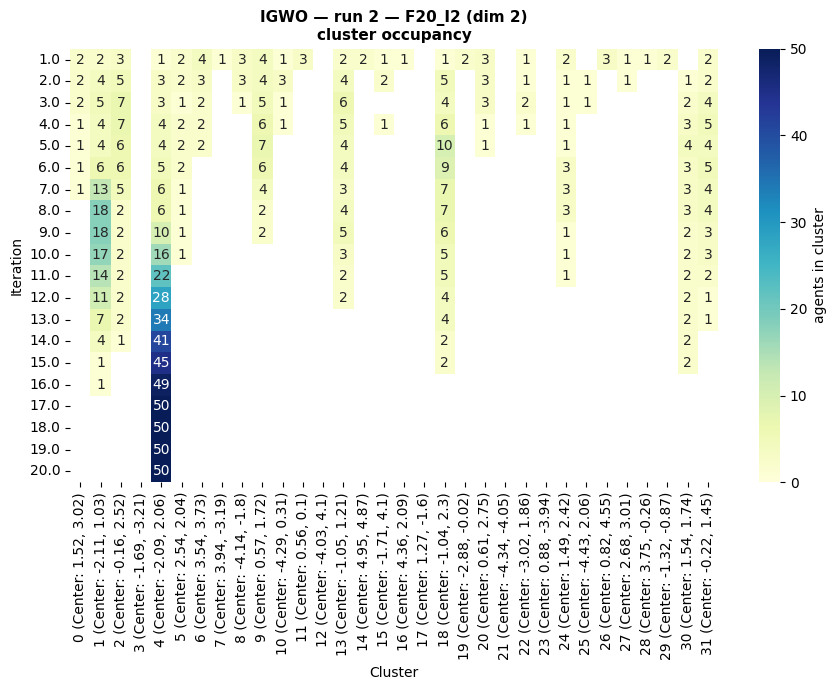

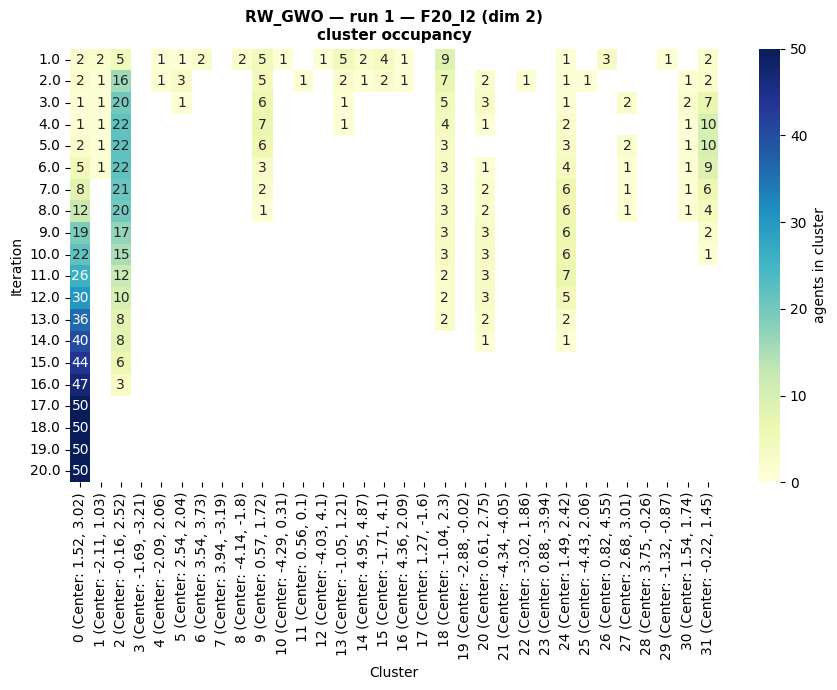

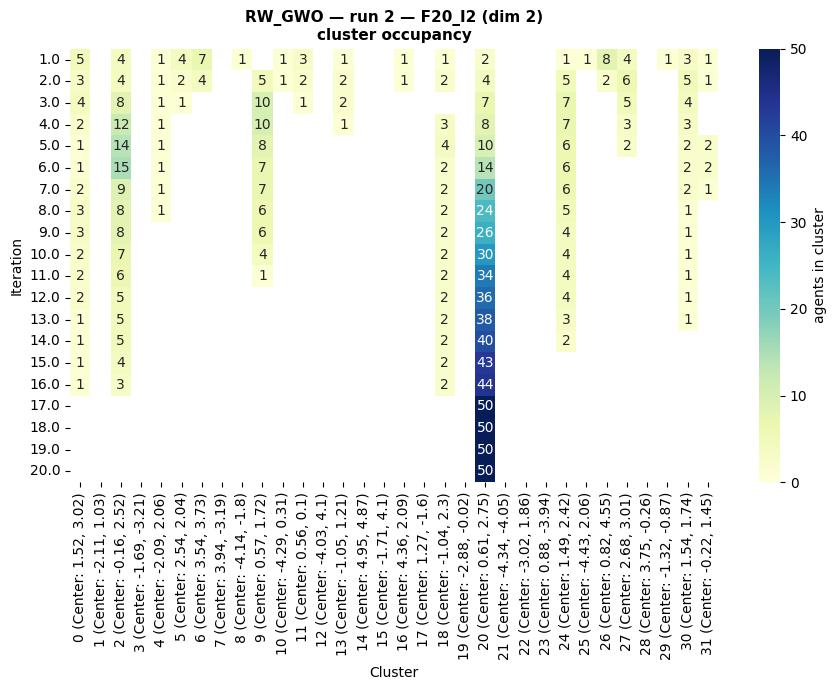

In [16]:
visualize([2], ['F20_I2'], ['IGWO', 'RW_GWO'], [1,2], data_dir=f'data/clustering_latest', plot_y=False, save=True)

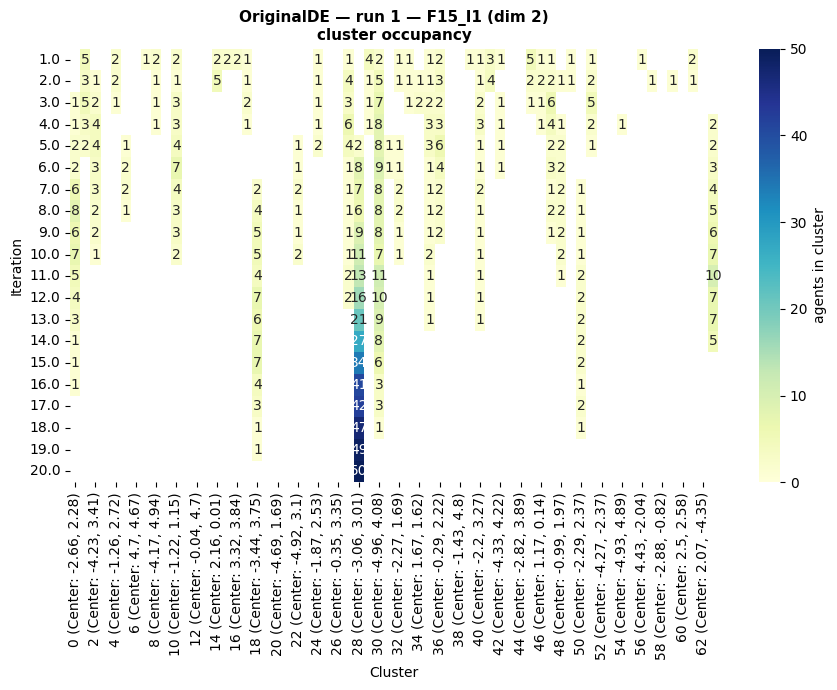

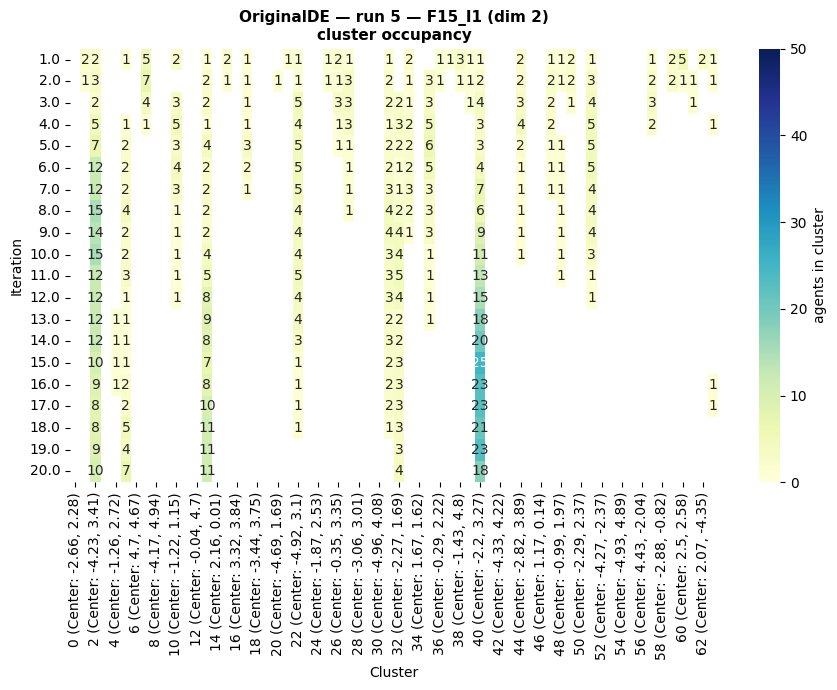

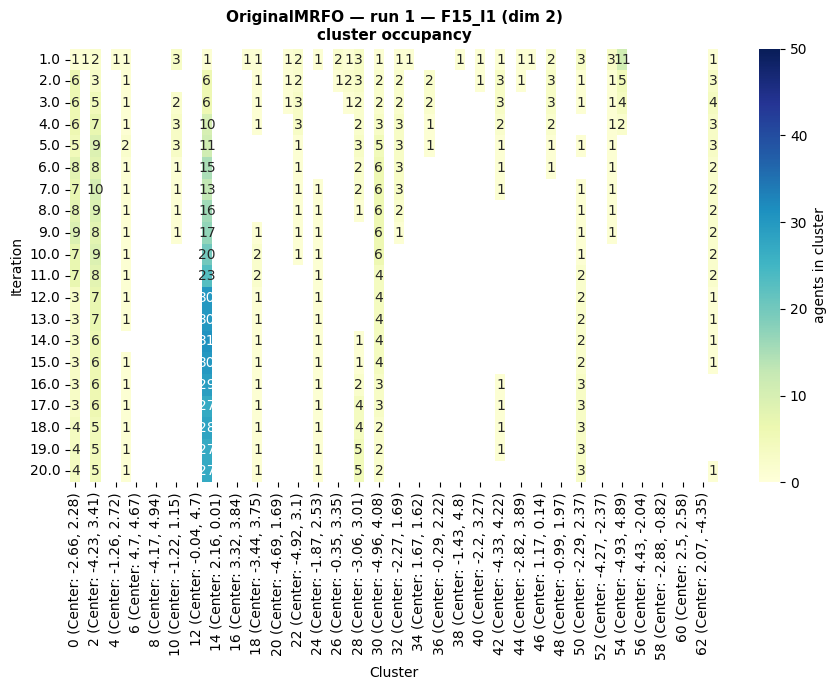

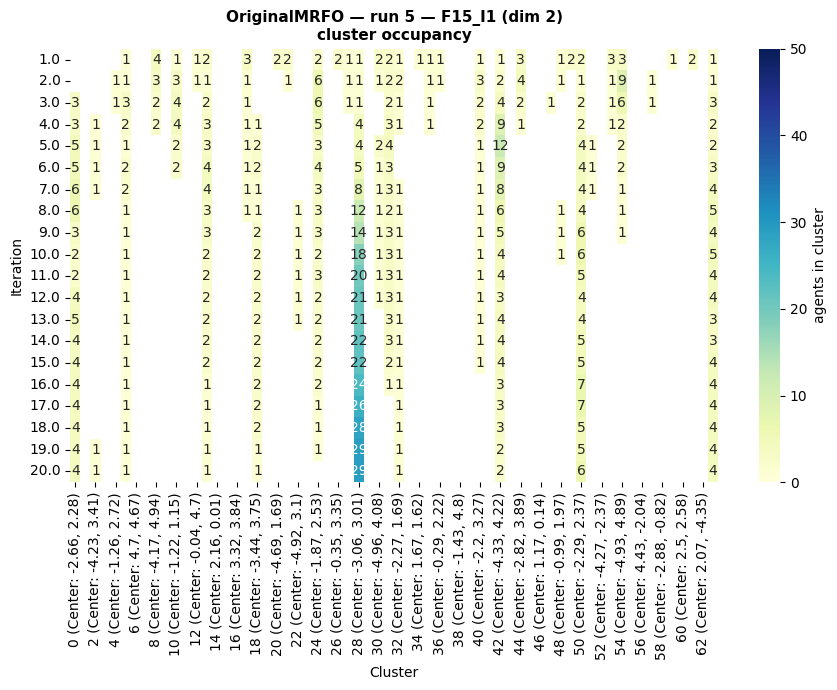

In [18]:
algorithms_of_interest=["OriginalDE","SADE","OriginalSHADE","AugmentedAEO", "GWO_WOA", "OriginalCSA", "OriginalMRFO"]

visualize([2], ['F15_I1'], ['OriginalDE', 'OriginalMRFO'], [1, 5],data_dir=f'data/clustering_latest', plot_y=False)

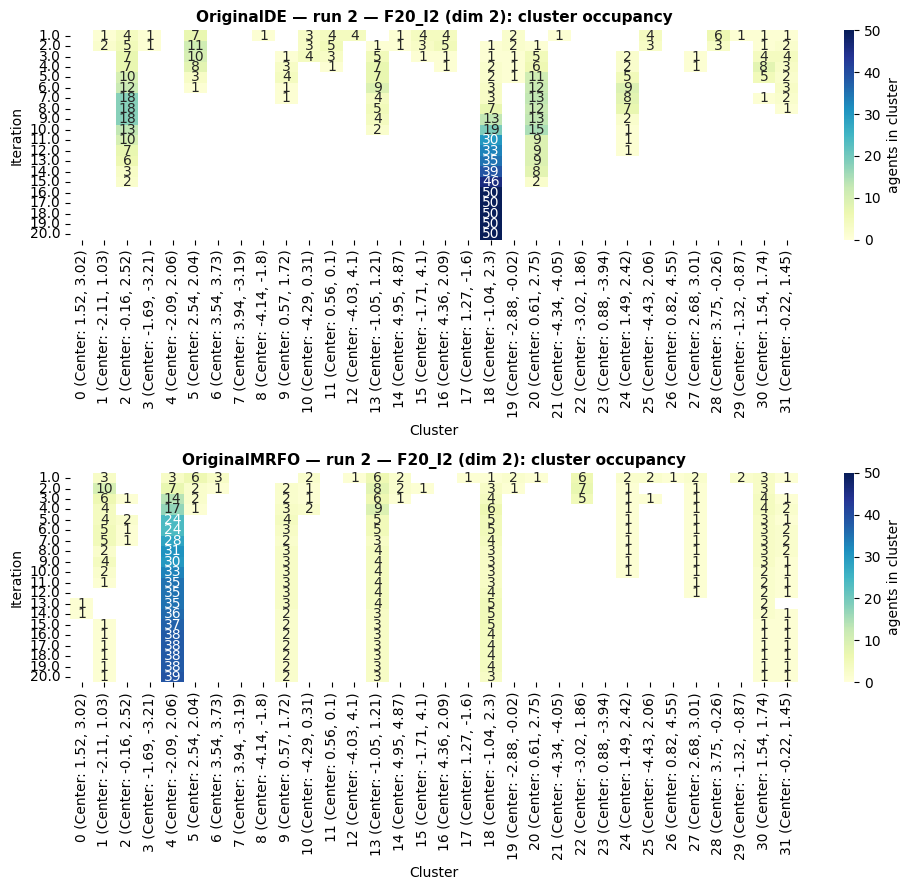

In [20]:
visualize_multi([2], ['F20_I2'], ['OriginalDE', 'OriginalMRFO'], [2], data_dir=f'data/clustering_latest', save=False)

    scaled_x0  scaled_x1
0   -3.303445  -2.962820
1    1.350965   0.688467
2    1.400151  -3.832897
3    4.225086   4.455563
4    2.252093  -1.488906
5   -2.740018   0.892692
6    1.989981   4.042554
7   -2.140412  -4.136986
8    0.733038   1.888724
9   -2.209210  -0.619855
10   4.367897  -2.143118
11  -0.735095   4.683686
12   3.013954  -3.185953
13   1.972030  -0.769760
14   3.880185  -4.558120
15  -4.798725   0.342154
16  -4.518104   4.240368
17  -1.110958  -3.246395
18  -0.034876   3.592588
19  -0.301760  -4.621817
20   1.272897   1.338807
21   4.004205   0.451838
22   3.347207   3.010330
23  -4.043459  -1.443845
24   1.623968   0.065314
25  -0.501379  -0.218162
26  -3.791171   2.418773
27   2.547969  -2.281921
28  -3.366302  -4.596074
29   5.366014   5.353303
30  -1.625630  -1.871988
31   0.104521   2.698452
{0: '-3.3, -2.96', 1: '1.35, 0.69', 2: '1.4, -3.83', 3: '4.23, 4.46', 4: '2.25, -1.49', 5: '-2.74, 0.89', 6: '1.99, 4.04', 7: '-2.14, -4.14', 8: '0.73, 1.89', 9: '-2.21, -0.62

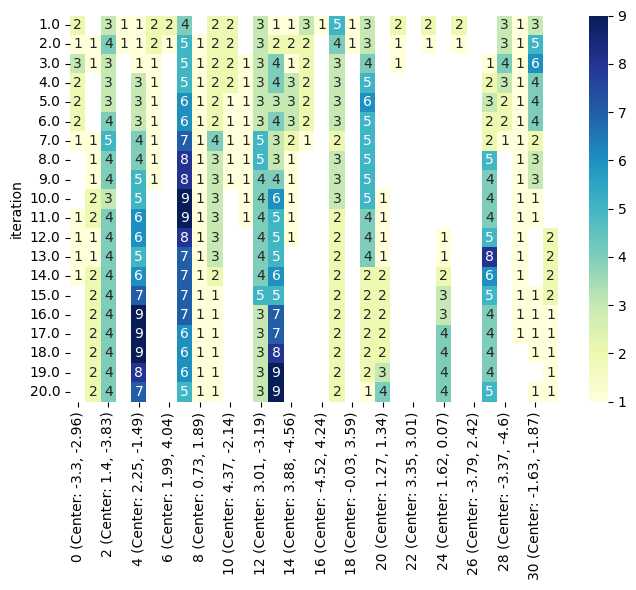

F22_I1 SADE 1
     iteration  cluster  scaled_raw_y
0          1.0        2  1.659979e-02
1          1.0        3  1.659979e-02
2          1.0        4  3.254980e-03
3          1.0        5  3.254980e-03
4          1.0        6  3.254980e-03
..         ...      ...           ...
417       20.0       20  1.941135e-07
418       20.0       24  1.941135e-07
419       20.0       27  1.941135e-07
420       20.0       30  1.941135e-07
421       20.0       31  1.941135e-07

[422 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


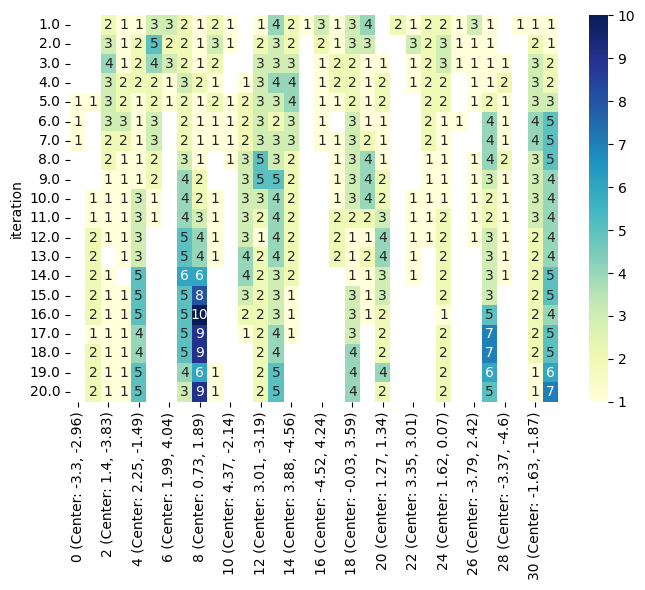

F22_I1 OriginalDE 1
     iteration  cluster  scaled_raw_y
0          1.0        0      0.129746
1          1.0        2      0.075678
2          1.0        3      0.075678
3          1.0        4      0.018392
4          1.0        5      0.016487
..         ...      ...           ...
109       16.0        4      0.000360
110       17.0        4      0.000356
111       18.0        4      0.000356
112       19.0        4      0.000352
113       20.0        4      0.000351

[114 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


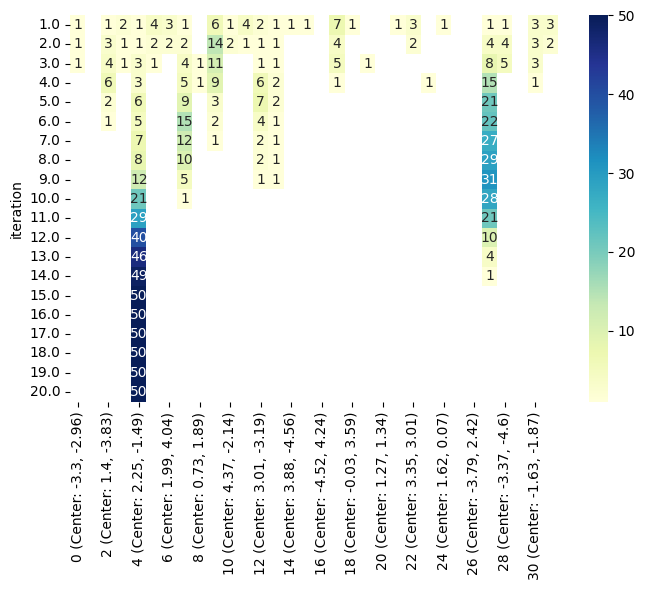

F22_I1 OriginalSHADE 1
     iteration  cluster  scaled_raw_y
0          1.0        0  1.589940e-02
1          1.0        1  1.589940e-02
2          1.0        2  1.589940e-02
3          1.0        3  1.589940e-02
4          1.0        5  1.589940e-02
..         ...      ...           ...
390       20.0       22  5.239346e-07
391       20.0       23  5.239346e-07
392       20.0       24  5.239346e-07
393       20.0       30  5.239346e-07
394       20.0       31  5.239346e-07

[395 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


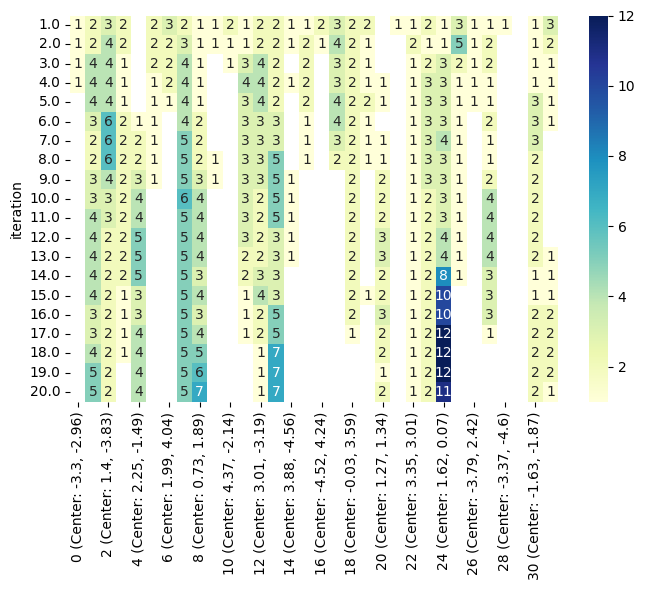

In [ ]:
visualize([2], ['F22_I1'], ['JADE','SADE', 'OriginalDE', 'OriginalSHADE'], [1],data_dir=f'data/clustering_latest', plot_y=False)

               x0        x1
cluster                    
0        1.729852 -0.107014
1       -2.108146 -4.064414
2        3.137685 -2.926323
3        3.013816 -2.712674
4        2.076122 -1.567749
5        0.342436  2.794042
6        0.196607  3.127413
7       -0.776240  4.990246
8       -0.468697  4.420479
9        3.695253  4.979582
10       1.372527 -3.863461
11       1.786065 -3.709730
{0: '1.73, -0.11', 1: '-2.11, -4.06', 2: '3.14, -2.93', 3: '3.01, -2.71', 4: '2.08, -1.57', 5: '0.34, 2.79', 6: '0.2, 3.13', 7: '-0.78, 4.99', 8: '-0.47, 4.42', 9: '3.7, 4.98', 10: '1.37, -3.86', 11: '1.79, -3.71'}
F22_I1 JADE 1
    iteration  cluster  scaled_raw_y
0         1.0        0      0.000695
1         1.0        1      0.000695
2         1.0       12      0.000695
3         2.0        0      0.000695
4         2.0        1      0.000695
..        ...      ...           ...
67       19.0        1      0.000028
68       19.0       12      0.000028
69       20.0        0      0.000028
70       

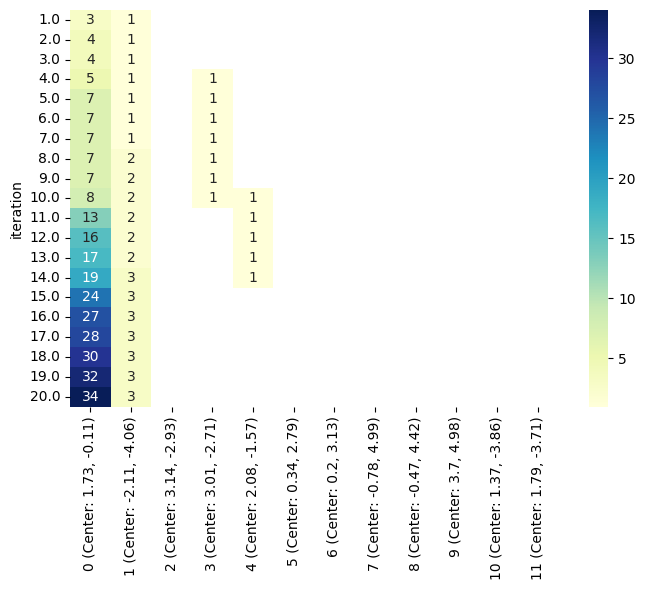

F22_I1 JADE 2
    iteration  cluster  scaled_raw_y
0         1.0        0  1.448633e-04
1         1.0       12  1.448633e-04
2         2.0        0  1.448633e-04
3         2.0       12  1.448633e-04
4         3.0        0  3.646967e-05
5         3.0       12  3.646967e-05
6         4.0        0  3.646967e-05
7         4.0       12  3.646967e-05
8         5.0        0  3.646967e-05
9         5.0        4  3.646967e-05
10        5.0       12  3.646967e-05
11        6.0        0  2.936462e-07
12        6.0        4  2.936462e-07
13        6.0       12  2.936462e-07
14        7.0        0  2.936462e-07
15        7.0        4  2.936462e-07
16        7.0       12  2.936462e-07
17        8.0        0  2.936462e-07
18        8.0        4  2.936462e-07
19        8.0       12  2.936462e-07
20        9.0        0  2.936462e-07
21        9.0        4  2.936462e-07
22        9.0       12  2.936462e-07
23       10.0        0  2.936462e-07
24       10.0        4  2.936462e-07
25       10.0       12  

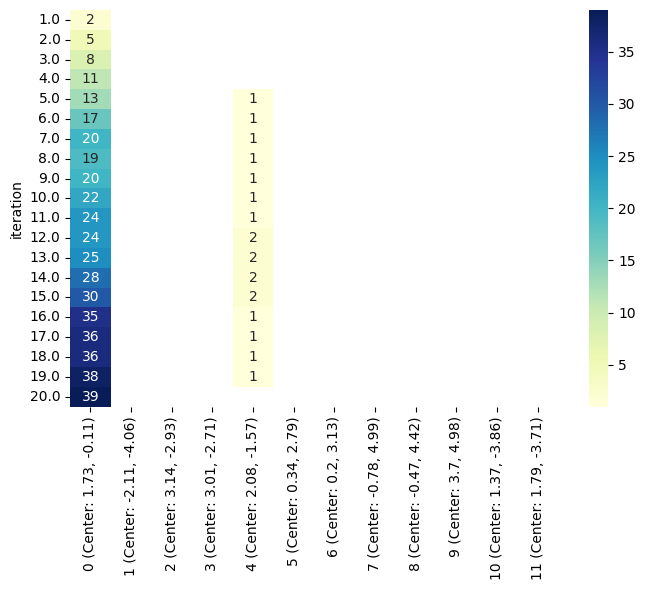

F22_I1 JADE 3
     iteration  cluster  scaled_raw_y
0          1.0       12  1.664504e-02
1          2.0        0  1.664504e-02
2          2.0       12  1.664504e-02
3          3.0        0  9.735603e-04
4          3.0       12  9.735603e-04
..         ...      ...           ...
96        20.0        4  5.226475e-07
97        20.0        6  5.226475e-07
98        20.0        8  5.226475e-07
99        20.0       11  5.226475e-07
100       20.0       12  5.226475e-07

[101 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


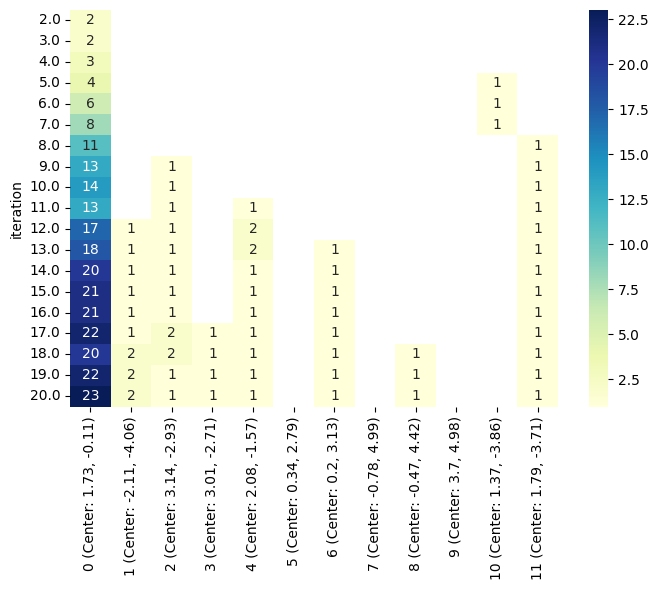

F22_I1 SADE 1
    iteration  cluster  scaled_raw_y
0         1.0        0  5.562651e-03
1         1.0        1  5.562651e-03
2         1.0       12  5.562651e-03
3         2.0        0  5.562651e-03
4         2.0        5  5.562651e-03
..        ...      ...           ...
75       19.0       12  8.971728e-07
76       20.0        0  8.971728e-07
77       20.0        4  8.971728e-07
78       20.0        7  8.971728e-07
79       20.0       12  8.971728e-07

[80 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


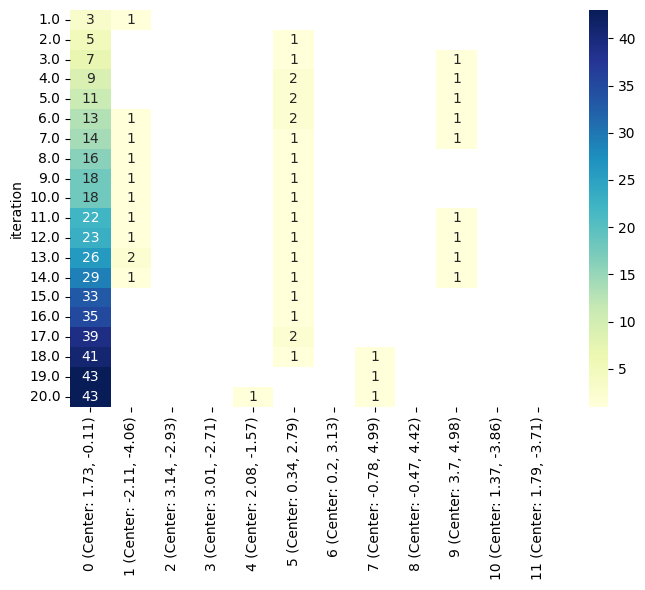

F22_I1 SADE 2
     iteration  cluster  scaled_raw_y
0          1.0        0      0.005585
1          1.0        5      0.005157
2          1.0       12      0.005157
3          2.0        0      0.001835
4          2.0        5      0.001835
..         ...      ...           ...
97        19.0       12      0.000001
98        20.0        0      0.000001
99        20.0        1      0.000001
100       20.0        2      0.000001
101       20.0       12      0.000001

[102 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


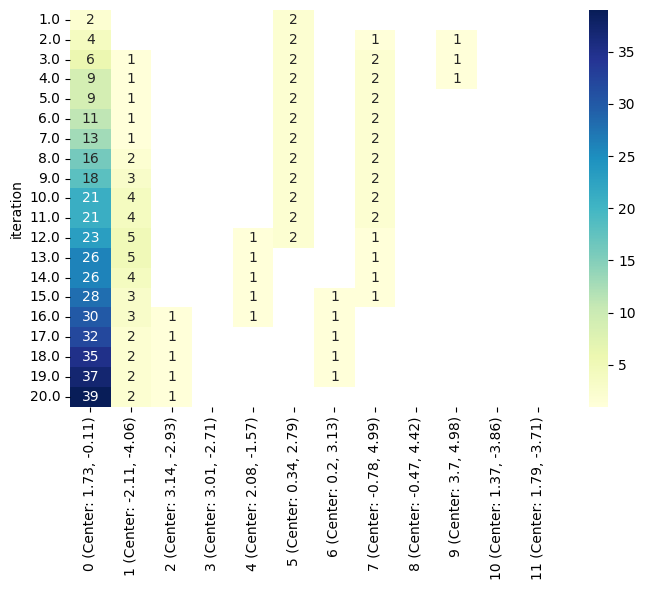

F22_I1 SADE 3
     iteration  cluster  scaled_raw_y
0          1.0        0  1.147716e-02
1          1.0        1  1.147716e-02
2          1.0       12  1.147716e-02
3          2.0        0  1.902050e-06
4          2.0        5  1.902050e-06
..         ...      ...           ...
96        20.0        1  5.236849e-07
97        20.0        5  5.236849e-07
98        20.0        6  5.236849e-07
99        20.0        8  5.236849e-07
100       20.0       12  5.236849e-07

[101 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


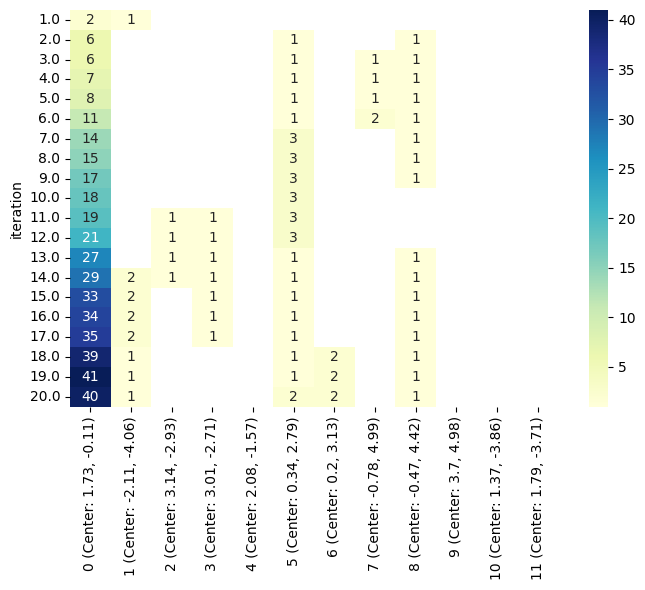

In [ ]:
visualize([2], ['F22_I1'], ['JADE','SADE'], [1,2,3],data_dir=f'data/clustering_features_10_algorithms_dbscan', plot_y=False)

In [13]:
dimension=2
directory=f'data/clustering_latest/cluster_distributions/dim_{dimension}'

trajectory_similarities=[]
for file in tqdm(os.listdir(directory)):
    file_loc=f'{directory}/{file}'
    if os.path.isfile(file_loc):
        df=pd.read_csv(file_loc,index_col=[0,1,2])
        d_algorithm_run=df.unstack(level=-1).dropna()
        #d_algorithm_run=pd.DataFrame(MinMaxScaler().fit_transform(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.columns).dropna()
        cs=pd.DataFrame(cosine_similarity(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.index)
        c=cs.reset_index().rename(columns={'algorithm':'algorithm2', 'run':'run2'}).melt(id_vars=[('algorithm2',  ''),('run2',  '')], value_vars=list(cs.columns)).rename(columns={('algorithm2',  ''): 'algorithm2', ('run2',''):'run2'})
        trajectory_similarities+=[c.assign(problem=file.replace('.csv',''))]

trajectory_similarities=pd.concat(trajectory_similarities)
t=trajectory_similarities.groupby('algorithm').count()['run']
t_max=t.max()
algorithms_to_remove=list(t[t<t_max].index)
trajectory_similarities=trajectory_similarities.query('algorithm not in @algorithms_to_remove and algorithm2 not in @algorithms_to_remove')
trajectory_similarities['problem_class']=[int(tt.split('_')[0].replace('F','')) for tt in trajectory_similarities['problem']]
trajectory_similarities['instance']=[int(tt.split('_')[1].replace('I','')) for tt in trajectory_similarities['problem']]
trajectory_similarities['run'] = trajectory_similarities['run'].astype(int)
trajectory_similarities['run2'] = trajectory_similarities['run2'].astype(int)

100%|██████████| 120/120 [00:02<00:00, 43.97it/s]


In [14]:
trajectory_similarities.query('algorithm!=algorithm2').sort_values('value')

,algorithm2,run2,algorithm,run,value,problem,problem_class,instance
19168,RW_GWO,4,WhaleFOA,2,0.000000,F2_I4,2,4
7417,WhaleFOA,3,OriginalALO,3,0.000000,F11_I1,11,1
7416,WhaleFOA,2,OriginalALO,3,0.000000,F11_I1,11,1
19558,OriginalMRFO,4,WhaleFOA,5,0.000000,F6_I5,6,5
19114,OriginalGWO,5,WhaleFOA,2,0.000000,F4_I4,4,4
...,...,...,...,...,...,...,...,...
658,OriginalMRFO,4,AugmentedAEO,5,0.999394,F5_I5,5,5
13768,OriginalAEO,4,OriginalMRFO,4,0.999402,F5_I1,5,1
6818,OriginalMRFO,4,OriginalAEO,4,0.999402,F5_I1,5,1
13301,AugmentedAEO,2,OriginalMRFO,1,0.999445,F5_I1,5,1


  0%|          | 0/120 [00:00<?, ?it/s]

100%|██████████| 120/120 [00:03<00:00, 31.83it/s]


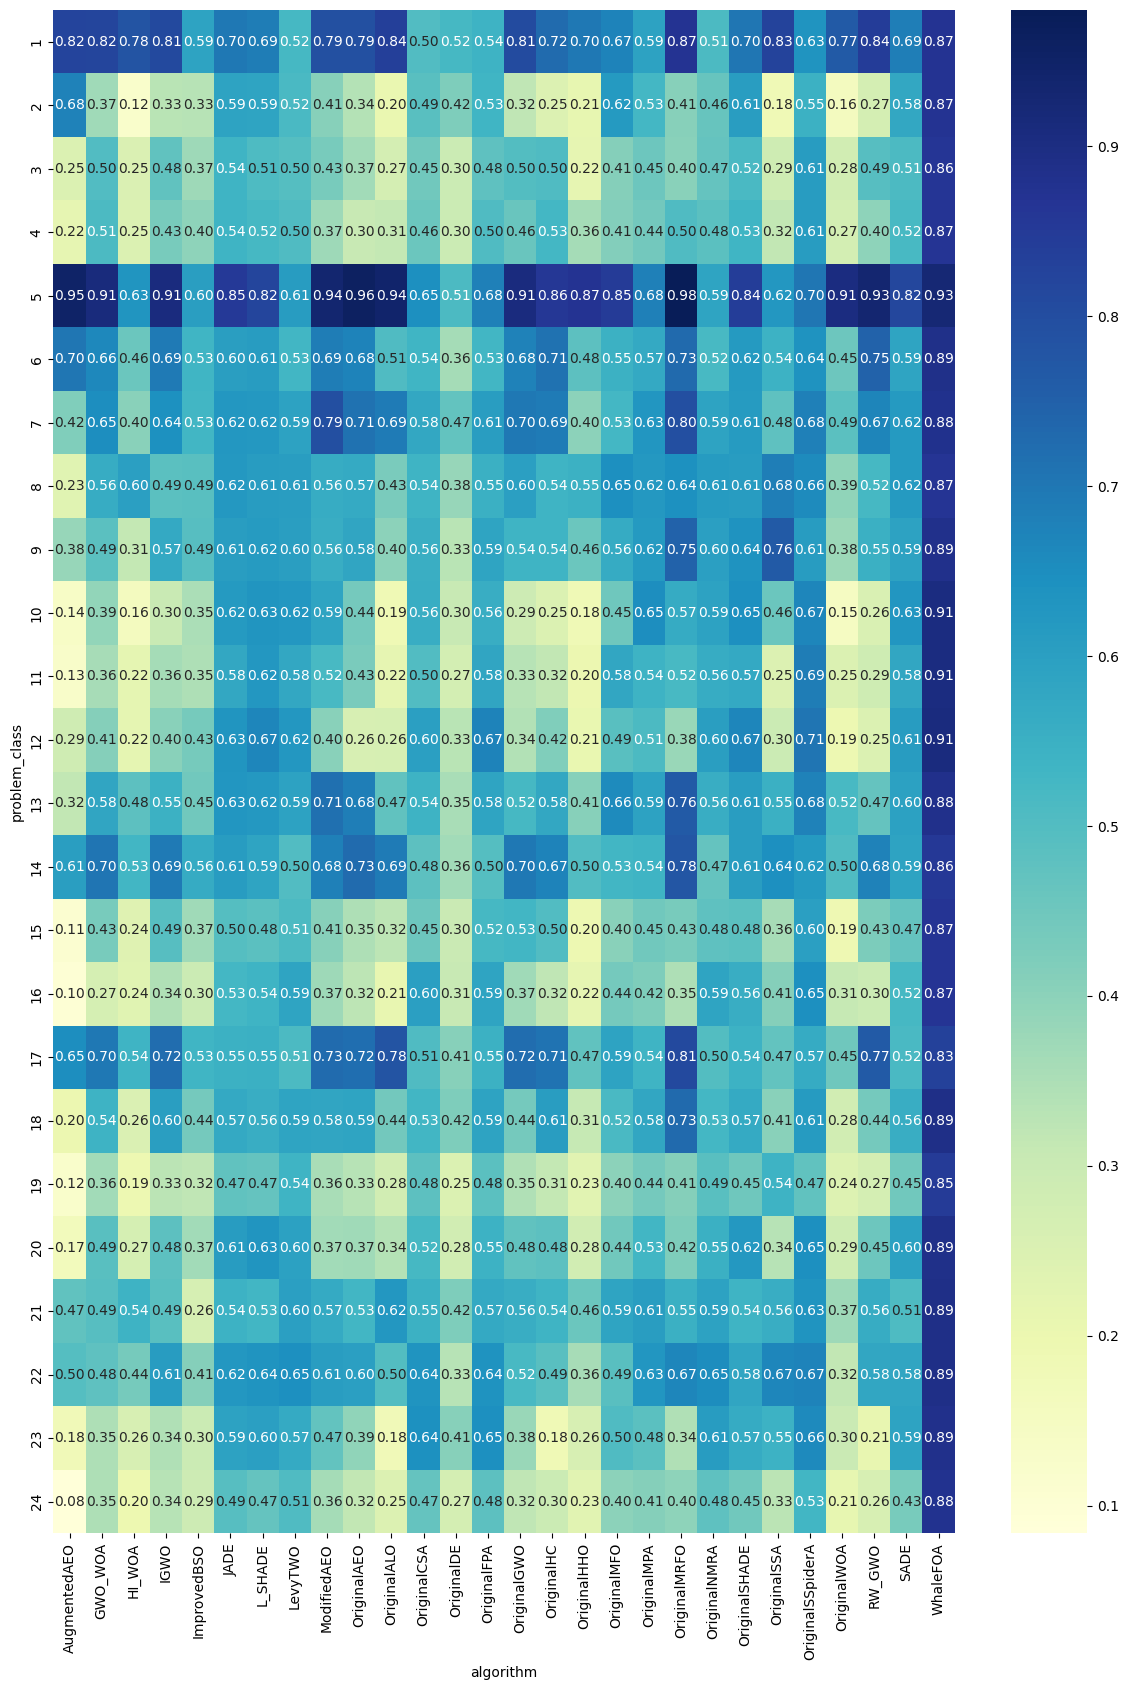

<Figure size 1500x1500 with 0 Axes>

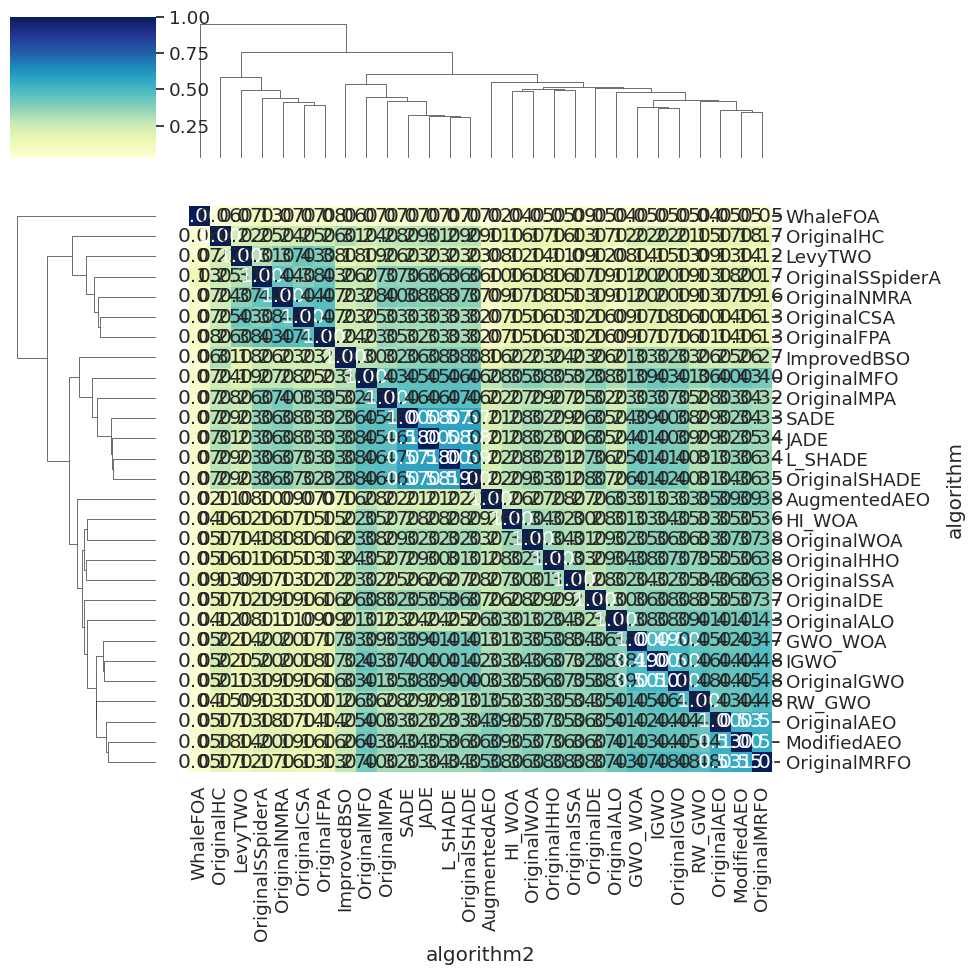

In [ ]:
for dimension in [2]:
    os.makedirs('figures_clustering_new_kmeans', exist_ok=True)
    directory=f'data/clustering_latest/cluster_distributions/dim_{dimension}'
    scale=False
    trajectory_similarities=[]
    for file in tqdm(os.listdir(directory)):
        file_loc=f'{directory}/{file}'
        if os.path.isfile(file_loc):
            df=pd.read_csv(file_loc,index_col=[0,1,2])
            d_algorithm_run=df.unstack(level=-1).dropna()
            d_algorithm_run=pd.DataFrame(MinMaxScaler().fit_transform(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.columns).dropna()
            cs=pd.DataFrame(cosine_similarity(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.index)
            c=cs.reset_index().rename(columns={'algorithm':'algorithm2', 'run':'run2'}).melt(id_vars=[('algorithm2',  ''),('run2',  '')], value_vars=list(cs.columns)).rename(columns={('algorithm2',  ''): 'algorithm2', ('run2',''):'run2'})
            trajectory_similarities+=[c.assign(problem=file.replace('.csv',''))]
    
    trajectory_similarities=pd.concat(trajectory_similarities)
    t=trajectory_similarities.groupby('algorithm').count()['run']
    t_max=t.max()
    algorithms_to_remove=list(t[t<t_max].index)
    trajectory_similarities=trajectory_similarities.query('algorithm not in @algorithms_to_remove and algorithm2 not in @algorithms_to_remove')
    trajectory_similarities['problem_class']=[int(tt.split('_')[0].replace('F','')) for tt in trajectory_similarities['problem']]
    trajectory_similarities['instance']=[int(tt.split('_')[1].replace('I','')) for tt in trajectory_similarities['problem']]
    trajectory_similarities['run'] = trajectory_similarities['run'].astype(int)
    trajectory_similarities['run2'] = trajectory_similarities['run2'].astype(int)

    plt.figure(figsize=(12,17))
    sim_per_problem_algorithm=trajectory_similarities.query('algorithm==algorithm2 and run!=run2').groupby(['problem_class','algorithm'])['value'].mean()
    sns.heatmap(sim_per_problem_algorithm.reset_index().pivot(index='problem_class',columns='algorithm',values='value').sort_index(),annot=True,fmt=".2f", cmap='YlGnBu')
    plt.tight_layout()
    plt.savefig(f'figures_clustering_new_kmeans/algorithm_similarity_per_problem_dim_{dimension}_scale_{scale}.pdf')

    cross_algorithm_similarity=trajectory_similarities.query('run==run2').groupby(['algorithm','algorithm2'])['value'].mean()
    cross_algorithm_similarity_pivoted=cross_algorithm_similarity.reset_index().pivot(index='algorithm',columns='algorithm2',values='value')
    sns.set_theme(font_scale=1.2)
    plt.figure(figsize=(15,15))
    sns.clustermap(cross_algorithm_similarity_pivoted,annot=True,fmt=".2f", cmap='YlGnBu')
    plt.tight_layout()
    plt.savefig(f'figures_clustering_new_kmeans/algorithm_mean_similarity_clustermap_dim_{dimension}_scale_{scale}.pdf')
    sns.set_theme(font_scale=1)


In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

FIG_DIR = 'figures_clustering_new_kmeans'

for dimension in [2]:
    os.makedirs(FIG_DIR, exist_ok=True)
    directory = f'data/clustering_latest/cluster_distributions/dim_{dimension}'
    scale = False

    # ---- build pairwise cosine similarities across all problems ----
    trajectory_similarities = []
    for file in tqdm(os.listdir(directory)):
        file_loc = f'{directory}/{file}'
        if not os.path.isfile(file_loc):
            continue
        df = pd.read_csv(file_loc, index_col=[0, 1, 2])
        d_algorithm_run = df.unstack(level=-1).dropna()
        d_algorithm_run = pd.DataFrame(
            MinMaxScaler().fit_transform(d_algorithm_run),
            index=d_algorithm_run.index,
            columns=d_algorithm_run.columns
        ).dropna()
        cs = pd.DataFrame(cosine_similarity(d_algorithm_run),
                          index=d_algorithm_run.index,
                          columns=d_algorithm_run.index)
        c = (cs.reset_index()
               .rename(columns={'algorithm': 'algorithm2', 'run': 'run2'})
               .melt(id_vars=[('algorithm2', ''), ('run2', '')], value_vars=list(cs.columns))
               .rename(columns={('algorithm2', ''): 'algorithm2', ('run2', ''): 'run2'}))
        trajectory_similarities += [c.assign(problem=file.replace('.csv', ''))]

    trajectory_similarities = pd.concat(trajectory_similarities)

    # drop algorithms with incomplete coverage
    t = trajectory_similarities.groupby('algorithm').count()['run']
    t_max = t.max()
    algorithms_to_remove = list(t[t < t_max].index)
    trajectory_similarities = trajectory_similarities.query(
        'algorithm not in @algorithms_to_remove and algorithm2 not in @algorithms_to_remove')

    trajectory_similarities['problem_class'] = [
        int(tt.split('_')[0].replace('F', '')) for tt in trajectory_similarities['problem']]
    trajectory_similarities['instance'] = [
        int(tt.split('_')[1].replace('I', '')) for tt in trajectory_similarities['problem']]
    trajectory_similarities['run'] = trajectory_similarities['run'].astype(int)
    trajectory_similarities['run2'] = trajectory_similarities['run2'].astype(int)

    # =====================================================================
    # FIGURE 1: self-similarity per problem-class x algorithm
    # 24 problem classes x ~28 algorithms. Annotations kept but shrunk -
    # at 672 cells they're borderline; set ANNOT_FIG1=False if too cramped.
    # =====================================================================
    ANNOT_FIG1 = True

    sim_per_problem_algorithm = (trajectory_similarities
                                 .query('algorithm==algorithm2 and run!=run2')
                                 .groupby(['problem_class', 'algorithm'])['value'].mean())
    pivot1 = (sim_per_problem_algorithm.reset_index()
              .pivot(index='problem_class', columns='algorithm', values='value')
              .sort_index())

    n_algos = pivot1.shape[1]
    # widen with the number of algorithms so 28 columns aren't crushed
    fig_w = max(12, n_algos * 0.75)
    plt.figure(figsize=(fig_w, 14))
    sns.heatmap(pivot1, annot=ANNOT_FIG1, fmt=".2f", cmap='YlGnBu',
                annot_kws={'size': 6} if ANNOT_FIG1 else None,
                cbar_kws={'label': 'mean cosine similarity (same algorithm, different runs)'})
    plt.title(f'Algorithm stability per problem class (dim {dimension})')
    plt.xlabel('Algorithm')
    plt.ylabel('Problem class')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/algorithm_similarity_per_problem_dim_{dimension}_scale_{scale}.pdf',
                bbox_inches='tight')
    plt.close()

    # =====================================================================
    # FIGURE 2: cross-algorithm clustermap (N x N)
    # With 28 algorithms that's 784 cells - annotations would be unreadable,
    # so annot=False. The value here is the DENDROGRAM STRUCTURE (which
    # algorithms group together) and the colour pattern, not individual
    # numbers. All algorithms kept so family groupings can actually emerge.
    # =====================================================================
    cross_algorithm_similarity = (trajectory_similarities
                                  .query('run==run2')
                                  .groupby(['algorithm', 'algorithm2'])['value'].mean())
    pivot2 = (cross_algorithm_similarity.reset_index()
              .pivot(index='algorithm', columns='algorithm2', values='value'))

    n = pivot2.shape[0]

    # NOTE: sns.clustermap creates its OWN figure - a preceding plt.figure()
    # is ignored (and leaves a stray empty canvas that plt.savefig might then
    # save instead). So: pass figsize to clustermap, and save via g.savefig.
    sns.set_theme(font_scale=1.0)
    g = sns.clustermap(pivot2, annot=False, cmap='YlGnBu',
                       figsize=(max(12, n * 0.5), max(12, n * 0.5)),
                       cbar_kws={'label': 'mean cosine similarity'})

    # Force ALL algorithm labels to show. matplotlib thins tick labels when
    # there are many rows, hiding names. Labels must be pulled in the
    # DENDROGRAM-REORDERED order, or every row gets the wrong name.
    row_order = g.dendrogram_row.reordered_ind
    g.ax_heatmap.set_yticks([i + 0.5 for i in range(n)])
    g.ax_heatmap.set_yticklabels([pivot2.index[i] for i in row_order],
                                 fontsize=8, rotation=0)

    col_order = g.dendrogram_col.reordered_ind
    g.ax_heatmap.set_xticks([i + 0.5 for i in range(pivot2.shape[1])])
    g.ax_heatmap.set_xticklabels([pivot2.columns[i] for i in col_order],
                                 fontsize=8, rotation=45, ha='right')

    g.ax_heatmap.set_xlabel('')
    g.ax_heatmap.set_ylabel('')
    g.figure.suptitle(f'Cross-algorithm trajectory similarity (dim {dimension})', y=1.02)

    g.savefig(f'{FIG_DIR}/algorithm_mean_similarity_clustermap_dim_{dimension}_scale_{scale}.pdf',
              bbox_inches='tight')
    plt.close()
    sns.set_theme(font_scale=1)

    print(f"dim {dimension}: {n} algorithms plotted")
    print(f"  removed (incomplete coverage): {algorithms_to_remove}")

  0%|          | 0/120 [00:00<?, ?it/s]

100%|██████████| 120/120 [00:03<00:00, 31.83it/s]


dim 2: 28 algorithms plotted
  removed (incomplete coverage): []


In [ ]:
optimizer_group=get_algorithm_groups()


In [ ]:
cross_algorithm_similarity_to_save=cross_algorithm_similarity.reset_index()
cross_algorithm_similarity_to_save['algorithm_group']=cross_algorithm_similarity_to_save['algorithm'].apply(lambda x: optimizer_group[x])
cross_algorithm_similarity_to_save['algorithm2_group']=cross_algorithm_similarity_to_save['algorithm2'].apply(lambda x: optimizer_group[x])
cross_algorithm_similarity_to_save.sort_values('value',ascending=False).query('algorithm!=algorithm2').to_csv(f'data/clustering_latest/algorithm_pairwise_similarity/algorithm_mean_similarity_{dimension}D.csv')

In [ ]:

unique_optimizer_groups=list(set(optimizer_group.values()))
#optimizer_group={k:str(v).split('.')[1] for k,v in optimizers.items()}
unique_colors=list(sns.color_palette("tab10"))
group_color={f:unique_colors[fi] for fi, f in enumerate(unique_optimizer_groups)}

unique_optimizer_groups=list(set(optimizer_group.values()))
#optimizer_group={k:str(v).split('.')[1] for k,v in optimizers.items()}
unique_colors=list(sns.color_palette("tab10"))
group_color={f:unique_colors[fi] for fi, f in enumerate(unique_optimizer_groups)}

In [ ]:
row_colors=[group_color[optimizer_group[o]] for o in cross_algorithm_similarity_pivoted.index]
col_colors=[group_color[optimizer_group[o]] for o in cross_algorithm_similarity_pivoted.columns]
sns.clustermap(cross_algorithm_similarity_pivoted, row_colors=row_colors, col_colors=col_colors,figsize=(40,40))
handles = [mpatches.Patch(color=color, label=label) for label, color in group_color.items()]
# Add legend to the clustermap
plt.legend(handles=handles, title='Algorithm group', bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure)

plt.savefig(f'figures_clustering_new_kmeans/algorithm_mean_similarity_clustermap_dim{dimension}.pdf')
#plt.show()
